In [2]:
%run ../scripts/train_haz.py

Train Mean Squared Error: 0.0263
Train R² Score: 0.9731
Test Mean Squared Error: 0.6871
Test R² Score: 0.4288
Đã huấn luyện và lưu mô hình: haz_prediction_model.pkl


OSError: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

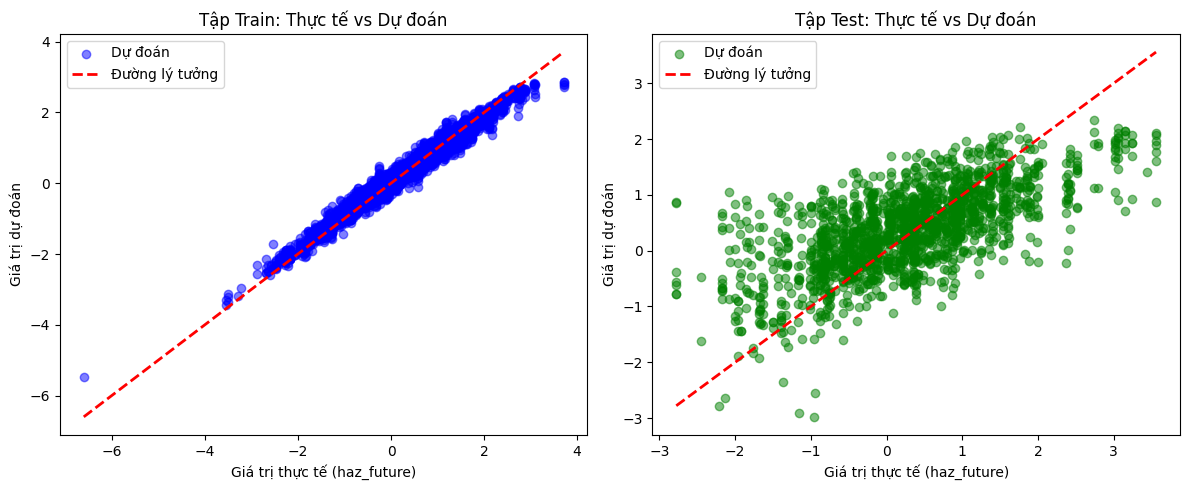

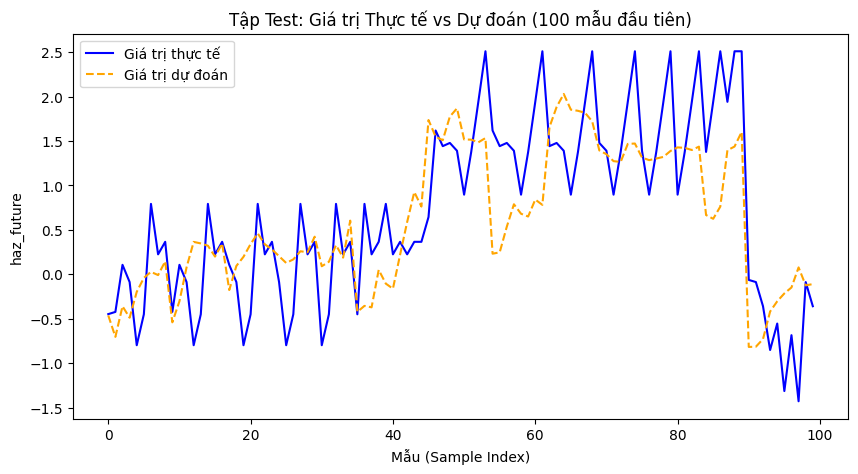

C:\Users\ngocl\AppData\Local\Temp\ipykernel_9472\442237806.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')


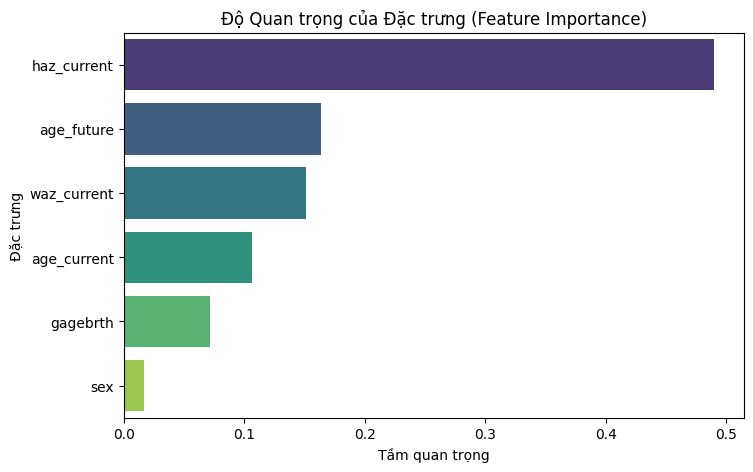

In [3]:
import matplotlib.pyplot as plt

# 1. Biểu đồ phân tán: Giá trị thực tế vs dự đoán
plt.figure(figsize=(12, 5))

# Tập train
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue', label='Dự đoán')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Đường lý tưởng')
plt.xlabel('Giá trị thực tế (haz_future)')
plt.ylabel('Giá trị dự đoán')
plt.title('Tập Train: Thực tế vs Dự đoán')
plt.legend()

# Tập test
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green', label='Dự đoán')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Đường lý tưởng')
plt.xlabel('Giá trị thực tế (haz_future)')
plt.ylabel('Giá trị dự đoán')
plt.title('Tập Test: Thực tế vs Dự đoán')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Biểu đồ giá trị thực tế và dự đoán theo mẫu (trên tập test)
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:100], label='Giá trị thực tế', color='blue')
plt.plot(y_test_pred[:100], label='Giá trị dự đoán', color='orange', linestyle='--')
plt.xlabel('Mẫu (Sample Index)')
plt.ylabel('haz_future')
plt.title('Tập Test: Giá trị Thực tế vs Dự đoán (100 mẫu đầu tiên)')
plt.legend()
plt.show()

# 3. Biểu đồ độ quan trọng của đặc trưng
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Độ Quan trọng của Đặc trưng (Feature Importance)')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.show()

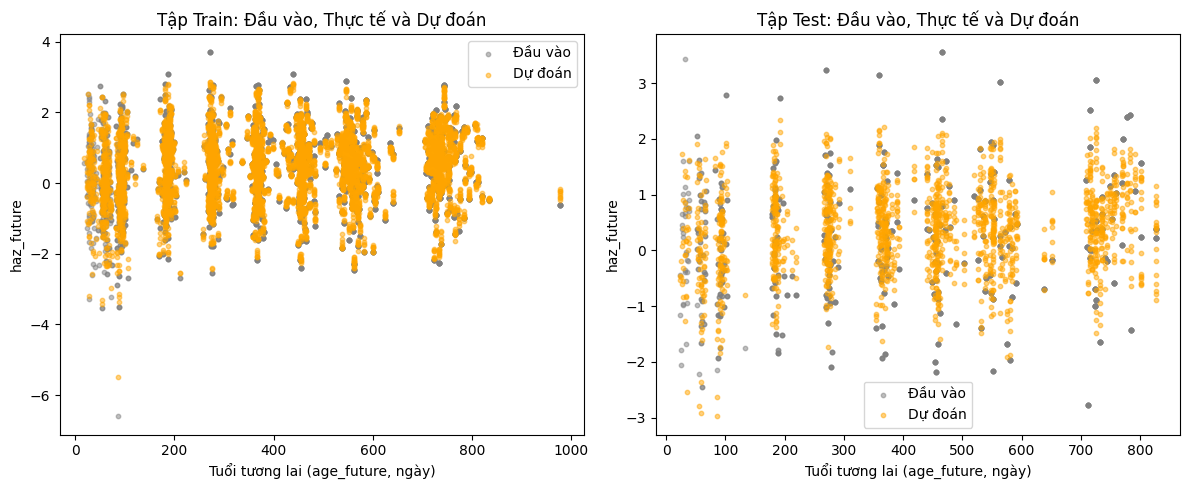

In [5]:
# 1. Biểu đồ: Các chấm đầu vào, đường thực tế, chấm dự đoán
plt.figure(figsize=(12, 5))

# Tập train
plt.subplot(1, 2, 1)
# Chấm đầu vào (dùng age_future làm trục x)
plt.scatter(X_train['age_future'], y_train, color='gray', alpha=0.5, label='Đầu vào', s=10)
# Đường giá trị thực tế
# plt.plot(X_train['age_future'], y_train, color='blue', label='Thực tế', linewidth=2)
# Chấm giá trị dự đoán
plt.scatter(X_train['age_future'], y_train_pred, color='orange', alpha=0.5, label='Dự đoán', s=10)
plt.xlabel('Tuổi tương lai (age_future, ngày)')
plt.ylabel('haz_future')
plt.title('Tập Train: Đầu vào, Thực tế và Dự đoán')
plt.legend()

# Tập test
plt.subplot(1, 2, 2)
# Chấm đầu vào (dùng age_future làm trục x)
plt.scatter(X_test['age_future'], y_test, color='gray', alpha=0.5, label='Đầu vào', s=10)
# Đường giá trị thực tế
# plt.plot(X_test['age_future'], y_test, color='blue', label='Thực tế', linewidth=2)
# Chấm giá trị dự đoán
plt.scatter(X_test['age_future'], y_test_pred, color='orange', alpha=0.5, label='Dự đoán', s=10)
plt.xlabel('Tuổi tương lai (age_future, ngày)')
plt.ylabel('haz_future')
plt.title('Tập Test: Đầu vào, Thực tế và Dự đoán')
plt.legend()

plt.tight_layout()
plt.show()

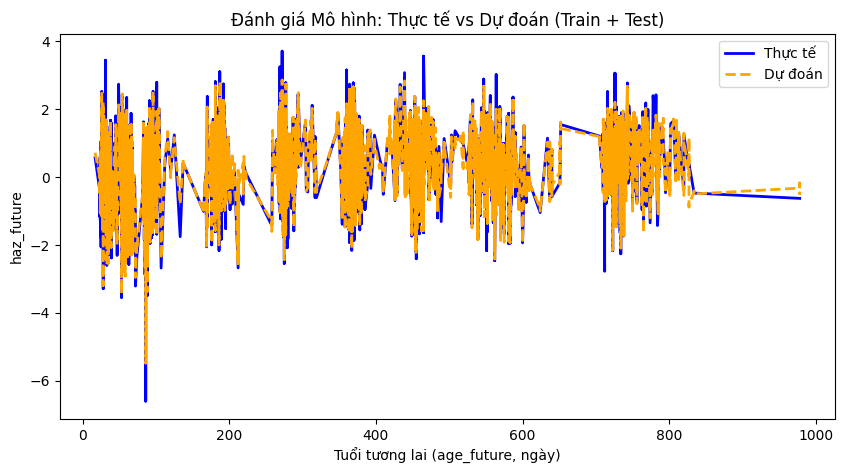

C:\Users\ngocl\AppData\Local\Temp\ipykernel_9472\4098064677.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')


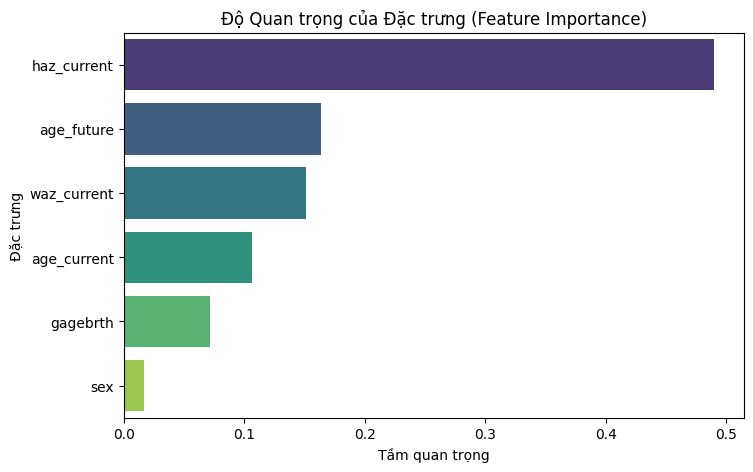

In [ ]:
# 2. Biểu đồ đánh giá mô hình: Đường thực tế và dự đoán trên toàn bộ dữ liệu (train + test)
# Gộp dữ liệu train và test
X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([pd.Series(y_train), pd.Series(y_test)], ignore_index=True)
y_all_pred = np.concatenate([y_train_pred, y_test_pred])

# Sắp xếp theo age_future để vẽ đường mượt mà hơn
sorted_indices = X_all['age_future'].argsort()
X_all_sorted = X_all.iloc[sorted_indices]
y_all_sorted = y_all.iloc[sorted_indices]
y_all_pred_sorted = y_all_pred[sorted_indices]

plt.figure(figsize=(10, 5))
plt.plot(X_all_sorted['age_future'], y_all_sorted, color='blue', label='Thực tế', linewidth=2)
plt.plot(X_all_sorted['age_future'], y_all_pred_sorted, color='orange', linestyle='--', label='Dự đoán', linewidth=2)
plt.xlabel('Tuổi tương lai (age_future, ngày)')
plt.ylabel('haz_future')
plt.title('Đánh giá Mô hình: Thực tế vs Dự đoán (Train + Test)')
plt.legend()
plt.show()

# 3. Biểu đồ độ quan trọng của đặc trưng (giữ nguyên)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Độ Quan trọng của Đặc trưng (Feature Importance)')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.show()

In [11]:
# Kiểm tra kiểu của model
print("Kiểu của model:", type(model))

Kiểu của model: <class 'numpy.ndarray'>


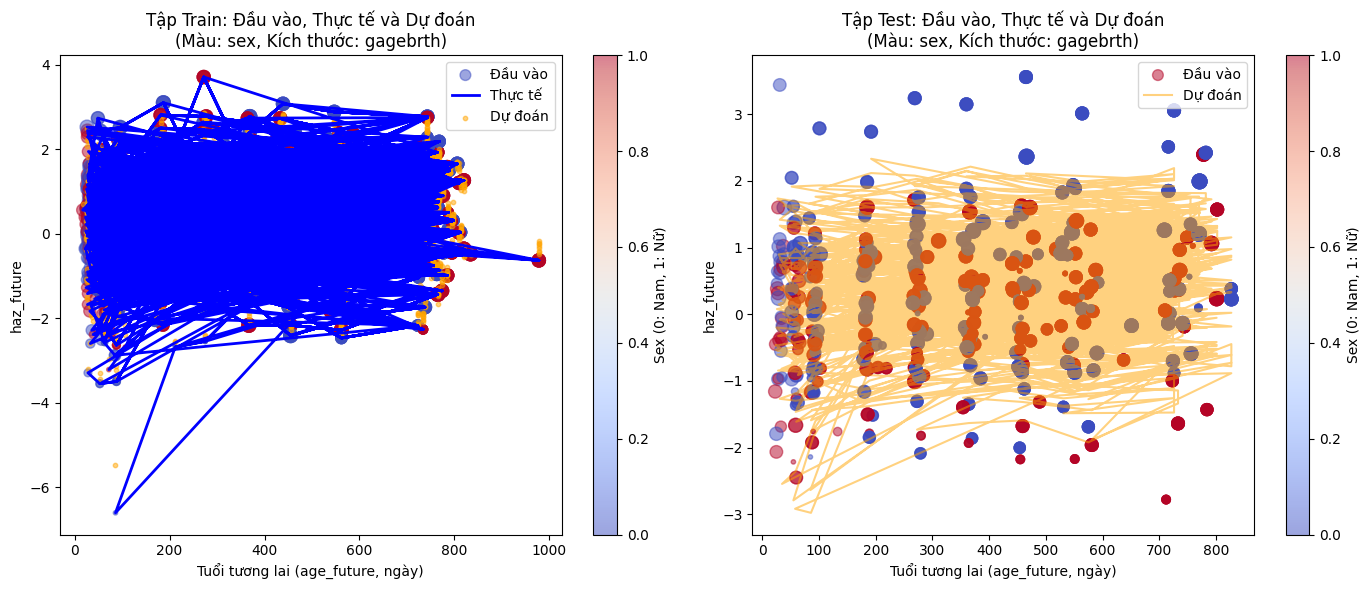

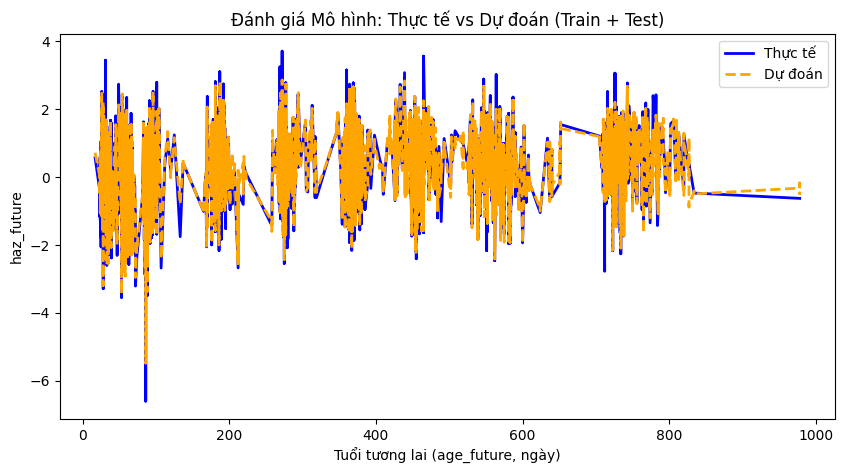

AttributeError: 'numpy.ndarray' object has no attribute 'feature_importances_'

In [8]:
import pickle

file_path = '../models/haz_prediction_model.pkl'

with open(file_path, 'rb') as file:
    model = pickle.load(file)

# 1. Biểu đồ: Các chấm đầu vào, đường thực tế, chấm dự đoán
plt.figure(figsize=(14, 6))

# Tập train
plt.subplot(1, 2, 1)
# Chấm đầu vào: age_future trên trục x, màu sắc theo sex, kích thước theo gagebrth
scatter_train = plt.scatter(X_train['age_future'], y_train, 
                            c=X_train['sex'], cmap='coolwarm', 
                            s=(X_train['gagebrth'] - X_train['gagebrth'].min()) / (X_train['gagebrth'].max() - X_train['gagebrth'].min()) * 100 + 10, 
                            alpha=0.5, label='Đầu vào')
# Đường giá trị thực tế
plt.plot(X_train['age_future'], y_train, color='blue', label='Thực tế', linewidth=2)
# Chấm giá trị dự đoán
plt.scatter(X_train['age_future'], y_train_pred, color='orange', alpha=0.5, label='Dự đoán', s=10)
plt.xlabel('Tuổi tương lai (age_future, ngày)')
plt.ylabel('haz_future')
plt.title('Tập Train: Đầu vào, Thực tế và Dự đoán\n(Màu: sex, Kích thước: gagebrth)')
plt.legend()
plt.colorbar(scatter_train, label='Sex (0: Nam, 1: Nữ)')

# Tập test
plt.subplot(1, 2, 2)
# Chấm đầu vào: age_future trên trục x, màu sắc theo sex, kích thước theo gagebrth
scatter_test = plt.scatter(X_test['age_future'], y_test, 
                           c=X_test['sex'], cmap='coolwarm', 
                           s=(X_test['gagebrth'] - X_test['gagebrth'].min()) / (X_test['gagebrth'].max() - X_test['gagebrth'].min()) * 100 + 10, 
                           alpha=0.5, label='Đầu vào')
# Đường giá trị thực tế
#plt.plot(X_test['age_future'], y_test, color='blue', label='Thực tế', linewidth=2)
# Chấm giá trị dự đoán
plt.plot(X_test['age_future'], y_test_pred, color='orange', alpha=0.5, label='Dự đoán')
plt.xlabel('Tuổi tương lai (age_future, ngày)')
plt.ylabel('haz_future')
plt.title('Tập Test: Đầu vào, Thực tế và Dự đoán\n(Màu: sex, Kích thước: gagebrth)')
plt.legend()
plt.colorbar(scatter_test, label='Sex (0: Nam, 1: Nữ)')

plt.tight_layout()
plt.show()

# 2. Biểu đồ đánh giá mô hình: Đường thực tế và dự đoán trên toàn bộ dữ liệu (train + test)
# Gộp dữ liệu train và test
X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([pd.Series(y_train), pd.Series(y_test)], ignore_index=True)
y_all_pred = np.concatenate([y_train_pred, y_test_pred])

# Sắp xếp theo age_future để vẽ đường mượt mà hơn
sorted_indices = X_all['age_future'].argsort()
X_all_sorted = X_all.iloc[sorted_indices]
y_all_sorted = y_all.iloc[sorted_indices]
y_all_pred_sorted = y_all_pred[sorted_indices]

plt.figure(figsize=(10, 5))
plt.plot(X_all_sorted['age_future'], y_all_sorted, color='blue', label='Thực tế', linewidth=2)
plt.plot(X_all_sorted['age_future'], y_all_pred_sorted, color='orange', linestyle='--', label='Dự đoán', linewidth=2)
plt.xlabel('Tuổi tương lai (age_future, ngày)')
plt.ylabel('haz_future')
plt.title('Đánh giá Mô hình: Thực tế vs Dự đoán (Train + Test)')
plt.legend()
plt.show()

# 3. Biểu đồ độ quan trọng của đặc trưng (giữ nguyên)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Độ Quan trọng của Đặc trưng (Feature Importance)')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.show()

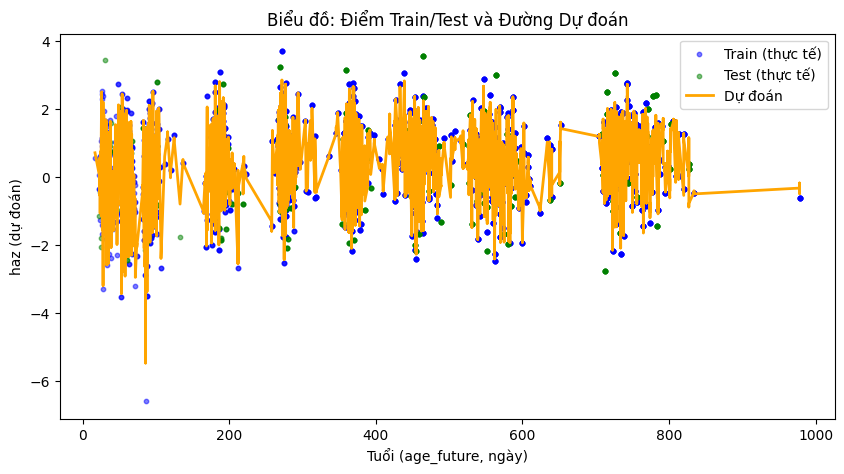

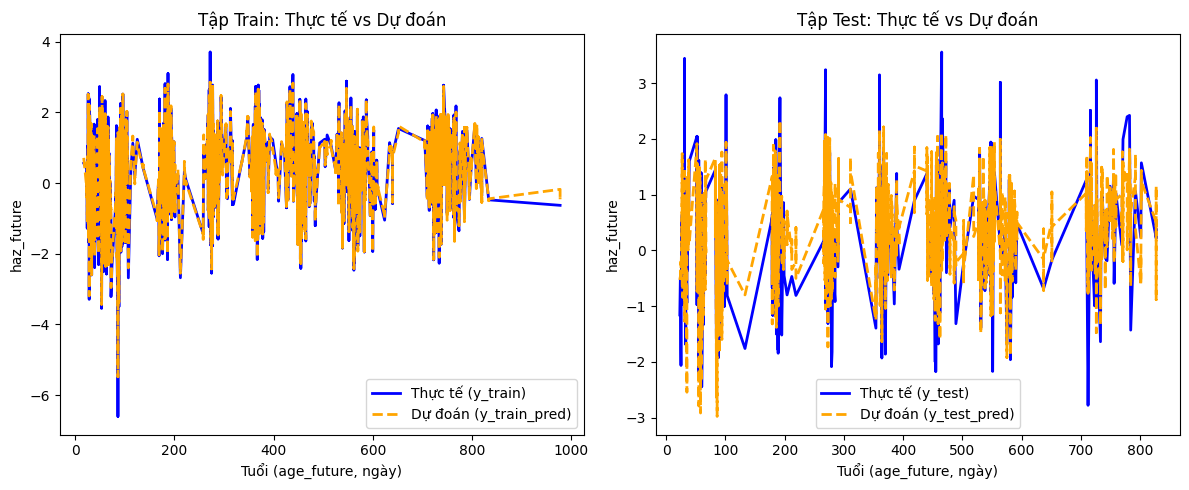

AttributeError: 'numpy.ndarray' object has no attribute 'feature_importances_'

In [9]:
# 1. Biểu đồ: Trục X là agedays, trục Y là haz (dự đoán), điểm train/test, đường dự đoán
plt.figure(figsize=(10, 5))

# Điểm dữ liệu đầu vào của tập train
plt.scatter(X_train['age_future'], y_train, color='blue', alpha=0.5, label='Train (thực tế)', s=10)
# Điểm dữ liệu đầu vào của tập test
plt.scatter(X_test['age_future'], y_test, color='green', alpha=0.5, label='Test (thực tế)', s=10)

# Gộp dữ liệu train và test để vẽ đường dự đoán
X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all_pred = np.concatenate([y_train_pred, y_test_pred])

# Sắp xếp theo age_future để vẽ đường mượt mà
sorted_indices = X_all['age_future'].argsort()
X_all_sorted = X_all.iloc[sorted_indices]
y_all_pred_sorted = y_all_pred[sorted_indices]

# Đường dự đoán
plt.plot(X_all_sorted['age_future'], y_all_pred_sorted, color='orange', label='Dự đoán', linewidth=2)

plt.xlabel('Tuổi (age_future, ngày)')
plt.ylabel('haz (dự đoán)')
plt.title('Biểu đồ: Điểm Train/Test và Đường Dự đoán')
plt.legend()
plt.show()

# 2. Biểu đồ đánh giá: 2 biểu đồ con cho tập train và test
plt.figure(figsize=(12, 5))

# Tập train
plt.subplot(1, 2, 1)
# Sắp xếp theo age_future để vẽ đường mượt mà
train_sorted_indices = X_train['age_future'].argsort()
X_train_sorted = X_train.iloc[train_sorted_indices]
y_train_sorted = y_train.iloc[train_sorted_indices]
y_train_pred_sorted = y_train_pred[train_sorted_indices]

plt.plot(X_train_sorted['age_future'], y_train_sorted, color='blue', label='Thực tế (y_train)', linewidth=2)
plt.plot(X_train_sorted['age_future'], y_train_pred_sorted, color='orange', linestyle='--', label='Dự đoán (y_train_pred)', linewidth=2)
plt.xlabel('Tuổi (age_future, ngày)')
plt.ylabel('haz_future')
plt.title('Tập Train: Thực tế vs Dự đoán')
plt.legend()

# Tập test
plt.subplot(1, 2, 2)
# Sắp xếp theo age_future để vẽ đường mượt mà
test_sorted_indices = X_test['age_future'].argsort()
X_test_sorted = X_test.iloc[test_sorted_indices]
y_test_sorted = y_test.iloc[test_sorted_indices]
y_test_pred_sorted = y_test_pred[test_sorted_indices]

plt.plot(X_test_sorted['age_future'], y_test_sorted, color='blue', label='Thực tế (y_test)', linewidth=2)
plt.plot(X_test_sorted['age_future'], y_test_pred_sorted, color='orange', linestyle='--', label='Dự đoán (y_test_pred)', linewidth=2)
plt.xlabel('Tuổi (age_future, ngày)')
plt.ylabel('haz_future')
plt.title('Tập Test: Thực tế vs Dự đoán')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Biểu đồ mức độ quan trọng
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Độ Quan trọng của Đặc trưng (Feature Importance)')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.show()

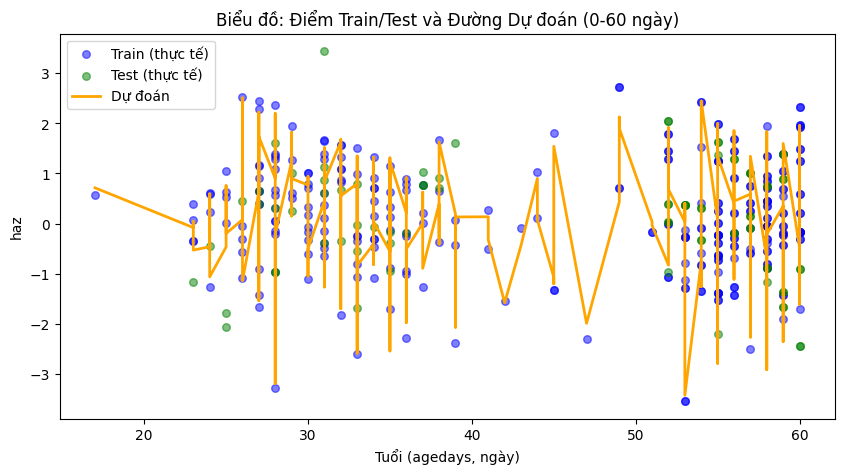

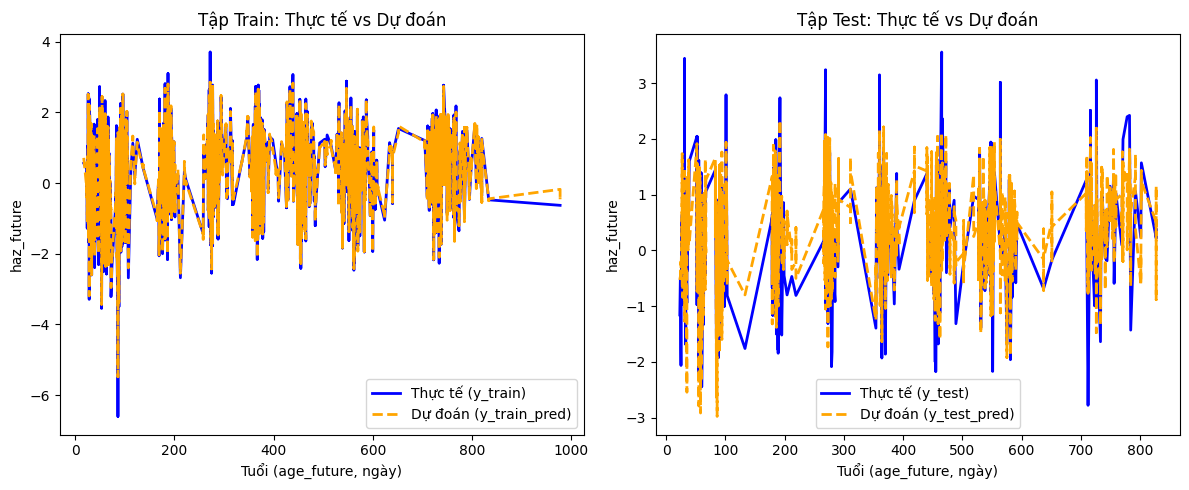

AttributeError: 'numpy.ndarray' object has no attribute 'feature_importances_'

In [10]:
# 1. Biểu đồ: Trục X là agedays (0-60 ngày), trục Y là haz, điểm train/test, đường dự đoán
# Lọc dữ liệu trong khoảng 0-60 ngày
train_mask = (X_train['age_future'] >= 0) & (X_train['age_future'] <= 60)
X_train_filtered = X_train[train_mask]
y_train_filtered = y_train[train_mask]
y_train_pred_filtered = y_train_pred[train_mask]

test_mask = (X_test['age_future'] >= 0) & (X_test['age_future'] <= 60)
X_test_filtered = X_test[test_mask]
y_test_filtered = y_test[test_mask]
y_test_pred_filtered = y_test_pred[test_mask]

plt.figure(figsize=(10, 5))

# Điểm dữ liệu của tập train
plt.scatter(X_train_filtered['age_future'], y_train_filtered, color='blue', alpha=0.5, label='Train (thực tế)', s=30)
# Điểm dữ liệu của tập test
plt.scatter(X_test_filtered['age_future'], y_test_filtered, color='green', alpha=0.5, label='Test (thực tế)', s=30)

# Gộp dữ liệu train và test để vẽ đường dự đoán
X_all_filtered = pd.concat([X_train_filtered, X_test_filtered], ignore_index=True)
y_all_pred_filtered = np.concatenate([y_train_pred_filtered, y_test_pred_filtered])

# Sắp xếp theo age_future để vẽ đường mượt mà
sorted_indices = X_all_filtered['age_future'].argsort()
X_all_sorted = X_all_filtered.iloc[sorted_indices]
y_all_pred_sorted = y_all_pred_filtered[sorted_indices]

# Đường dự đoán
plt.plot(X_all_sorted['age_future'], y_all_pred_sorted, color='orange', label='Dự đoán', linewidth=2)

plt.xlabel('Tuổi (agedays, ngày)')
plt.ylabel('haz')
plt.title('Biểu đồ: Điểm Train/Test và Đường Dự đoán (0-60 ngày)')
plt.legend()
plt.show()

# 2. Biểu đồ đánh giá: 2 biểu đồ con cho tập train và test
plt.figure(figsize=(12, 5))

# Tập train
plt.subplot(1, 2, 1)
train_sorted_indices = X_train['age_future'].argsort()
X_train_sorted = X_train.iloc[train_sorted_indices]
y_train_sorted = y_train.iloc[train_sorted_indices]
y_train_pred_sorted = y_train_pred[train_sorted_indices]

plt.plot(X_train_sorted['age_future'], y_train_sorted, color='blue', label='Thực tế (y_train)', linewidth=2)
plt.plot(X_train_sorted['age_future'], y_train_pred_sorted, color='orange', linestyle='--', label='Dự đoán (y_train_pred)', linewidth=2)
plt.xlabel('Tuổi (age_future, ngày)')
plt.ylabel('haz_future')
plt.title('Tập Train: Thực tế vs Dự đoán')
plt.legend()

# Tập test
plt.subplot(1, 2, 2)
test_sorted_indices = X_test['age_future'].argsort()
X_test_sorted = X_test.iloc[test_sorted_indices]
y_test_sorted = y_test.iloc[test_sorted_indices]
y_test_pred_sorted = y_test_pred[test_sorted_indices]

plt.plot(X_test_sorted['age_future'], y_test_sorted, color='blue', label='Thực tế (y_test)', linewidth=2)
plt.plot(X_test_sorted['age_future'], y_test_pred_sorted, color='orange', linestyle='--', label='Dự đoán (y_test_pred)', linewidth=2)
plt.xlabel('Tuổi (age_future, ngày)')
plt.ylabel('haz_future')
plt.title('Tập Test: Thực tế vs Dự đoán')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Biểu đồ mức độ quan trọng
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Độ Quan trọng của Đặc trưng (Feature Importance)')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.show()

In [3]:
%run "..\scripts\train_haz.py"

Train Mean Squared Error: 0.2493
Train R² Score: 0.7445
Test Mean Squared Error: 0.6322
Test R² Score: 0.4744
Cross-Validation R² Scores: [0.36385476 0.32116444 0.49605765 0.31676348 0.44105344]
Mean CV R² Score: 0.3878
Standard Deviation CV R² Score: 0.0702
Đã huấn luyện và lưu mô hình tại: d:\Child_height_prediction\models\haz_prediction_model.pkl
Đã lưu dữ liệu train và test vào thư mục data.


Kiểu của model: <class 'sklearn.ensemble._forest.RandomForestRegressor'>


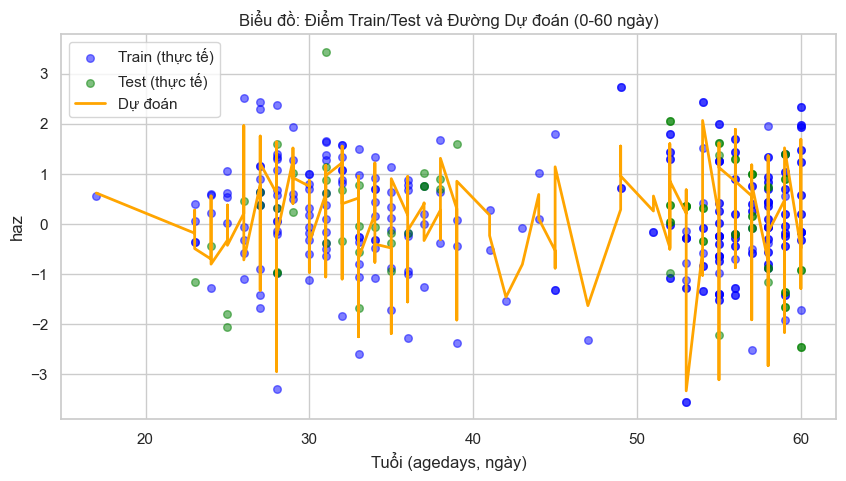

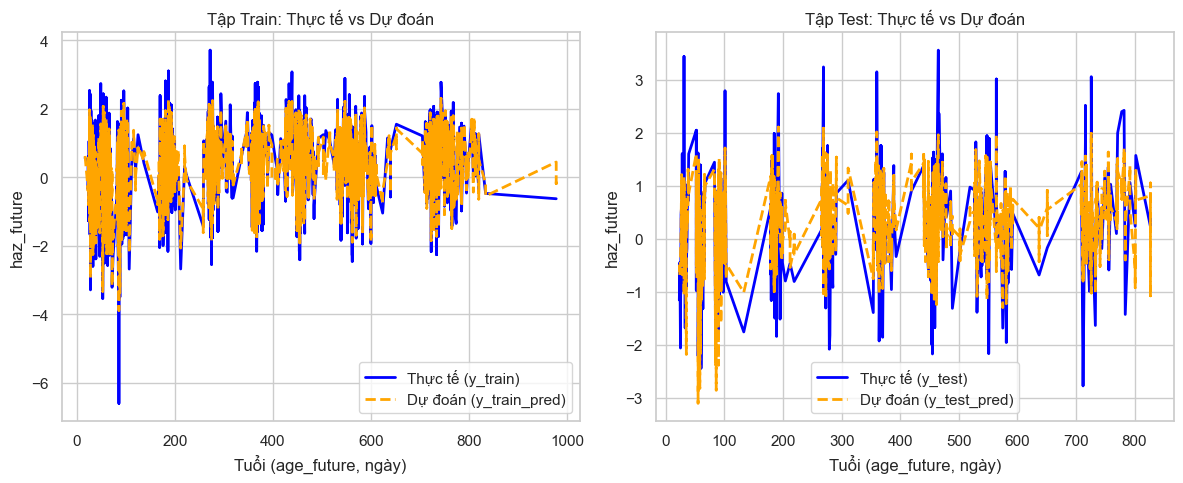

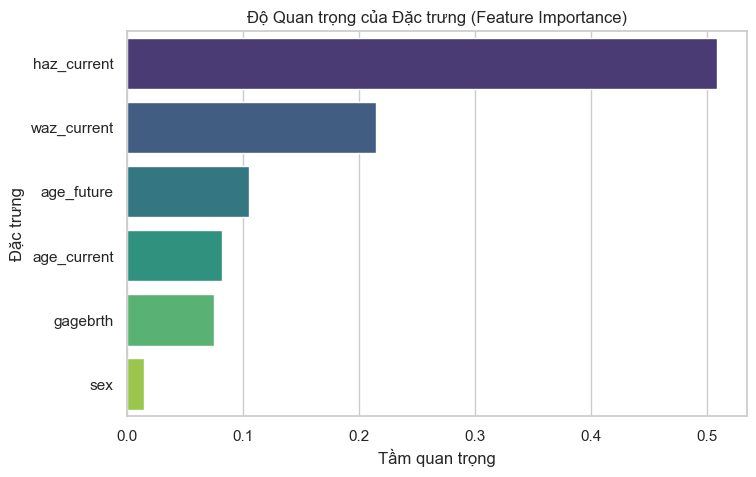

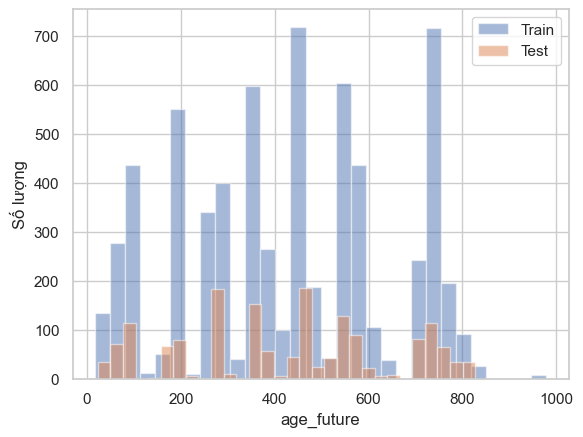

In [4]:
%run "..\scripts\visualize_haz_model.py"

In [5]:
%run "..\scripts\train_haz_split_sex.py"

Kết quả cho mô hình nam:
Train Mean Squared Error: 0.1970
Train R² Score: 0.7972
Test Mean Squared Error: 0.7024
Test R² Score: 0.4933

Kết quả cho mô hình nữ:
Train Mean Squared Error: 0.1715
Train R² Score: 0.8244
Test Mean Squared Error: 0.6172
Test R² Score: 0.3354
Đã lưu mô hình nam tại: d:\Child_height_prediction\models\haz_model_male.pkl
Đã lưu mô hình nữ tại: d:\Child_height_prediction\models\haz_model_female.pkl
Đã lưu dữ liệu train và test riêng cho nam và nữ vào thư mục data.


Kiểu của mô hình nam: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Kiểu của mô hình nữ: <class 'sklearn.ensemble._forest.RandomForestRegressor'>

Biểu đồ cho mô hình nam:


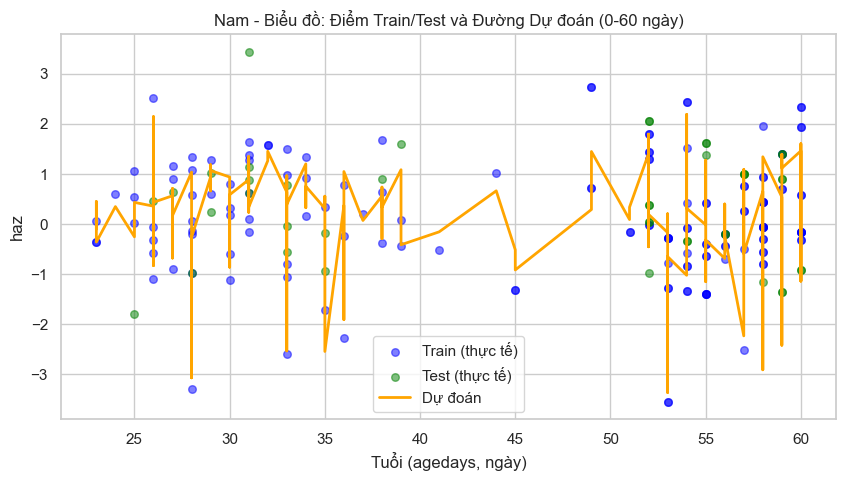

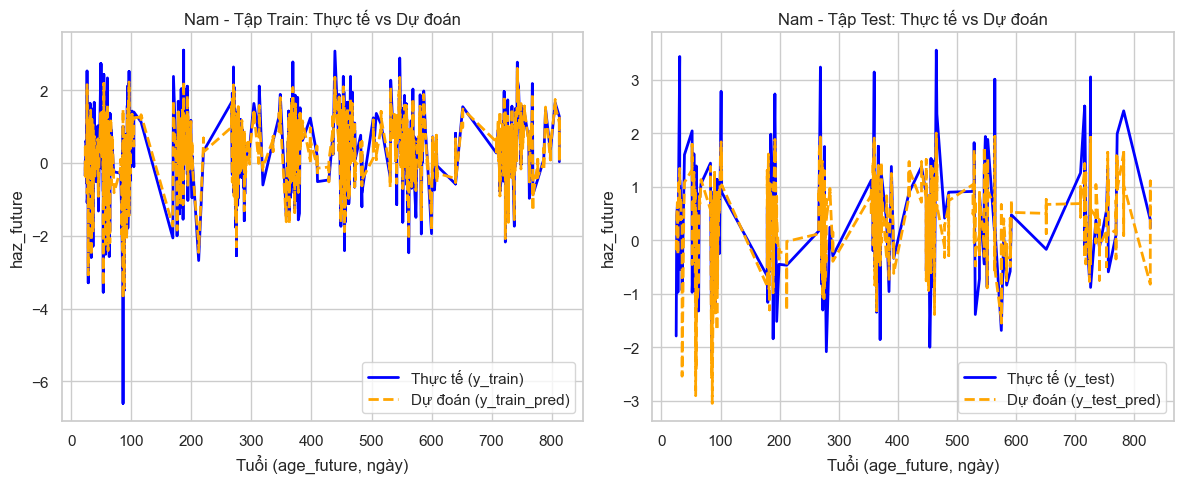

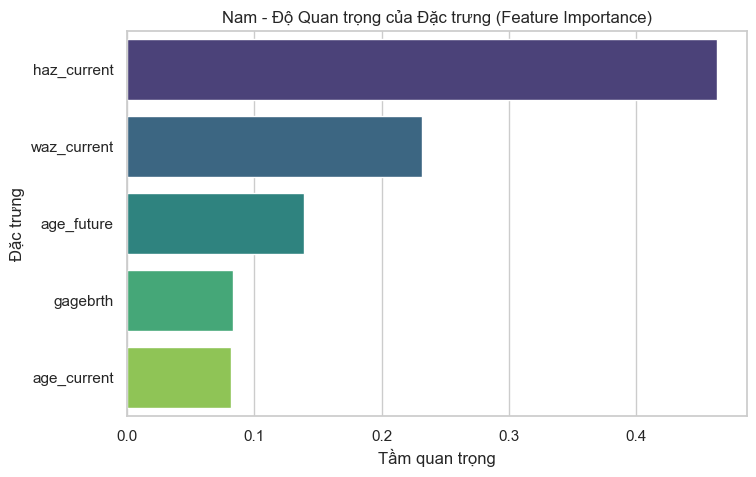


Biểu đồ cho mô hình nữ:


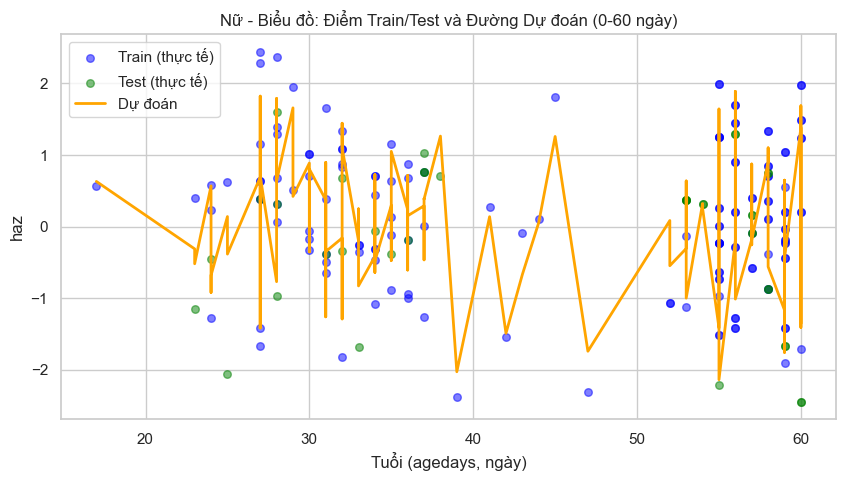

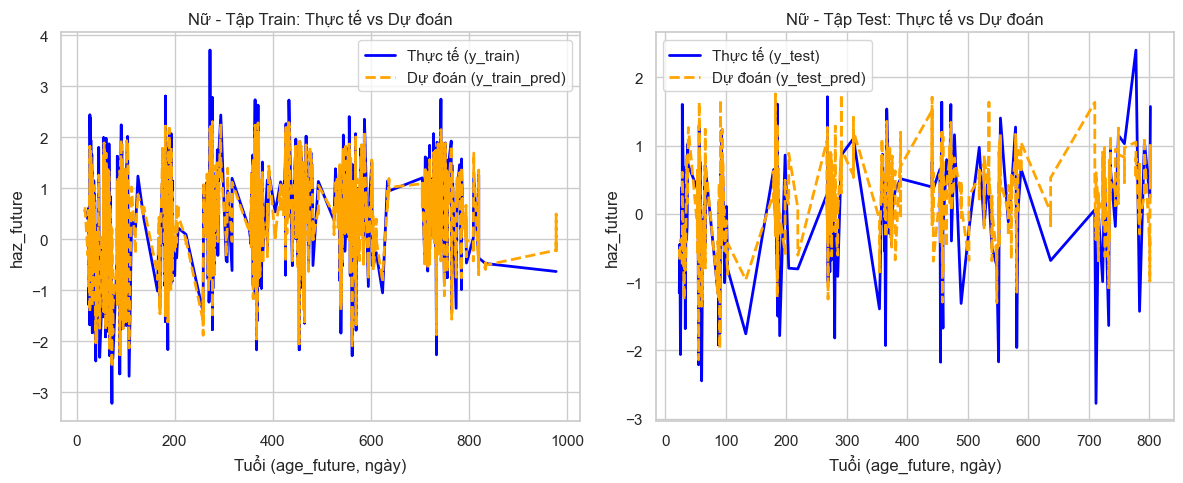

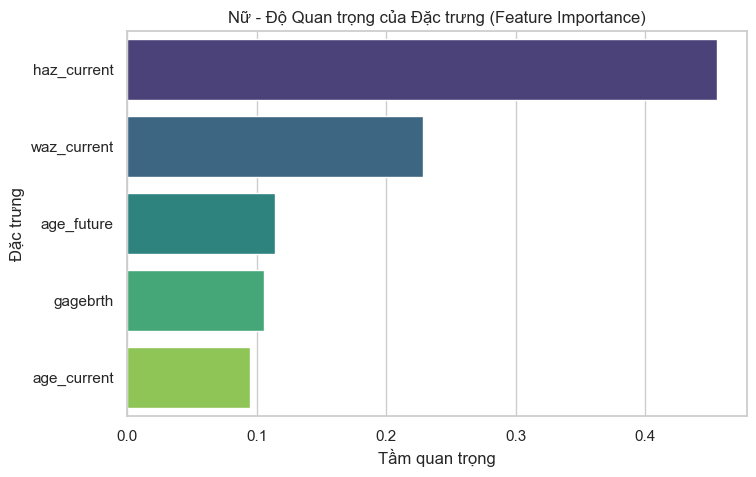

In [6]:
%run "..\scripts\visualize_haz_model_split_sex.py"

In [16]:
%run "..\scripts\train_haz_split_sex.py"

Kết quả cho mô hình nam:
Train Mean Squared Error: 0.1858
Train R² Score: 0.7972
Test Mean Squared Error: 0.6885
Test R² Score: 0.5034

Kết quả cho mô hình nữ:
Train Mean Squared Error: 0.1650
Train R² Score: 0.8256
Test Mean Squared Error: 0.6311
Test R² Score: 0.3205
Cross-Validation R² Scores (Nam): [ 0.23482995 -0.26714121  0.44308617  0.26126933  0.15469743]
Mean CV R² Score (Nam): 0.1653
Standard Deviation CV R² Score (Nam): 0.2359
Cross-Validation R² Scores (Nữ): [0.40074977 0.38147177 0.20278532 0.28602081 0.45019358]
Mean CV R² Score (Nữ): 0.3442
Standard Deviation CV R² Score (Nữ): 0.0885
Đã lưu mô hình nam tại: d:\Child_height_prediction\models\haz_model_male.pkl
Đã lưu mô hình nữ tại: d:\Child_height_prediction\models\haz_model_female.pkl
Đã lưu dữ liệu train và test riêng cho nam và nữ vào thư mục data.


Kiểu của mô hình nam: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Kiểu của mô hình nữ: <class 'sklearn.ensemble._forest.RandomForestRegressor'>

Biểu đồ cho mô hình nam:


d:\Child_height_prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
d:\Child_height_prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
d:\Child_height_prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
d:\Child_height_prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


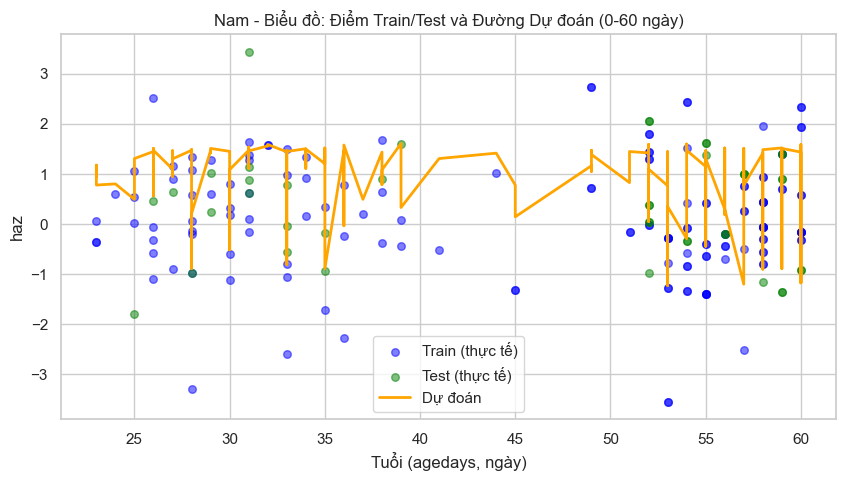

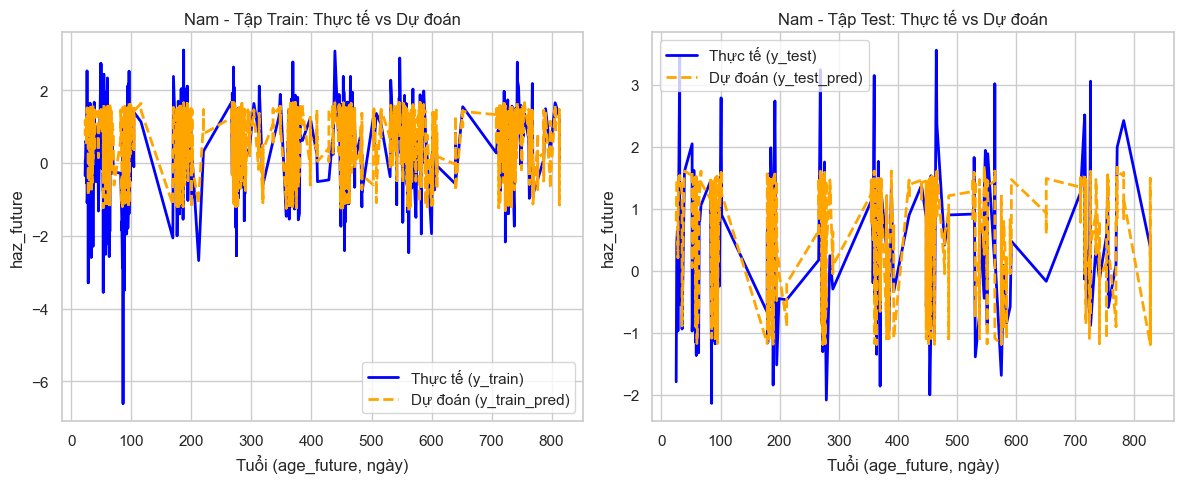

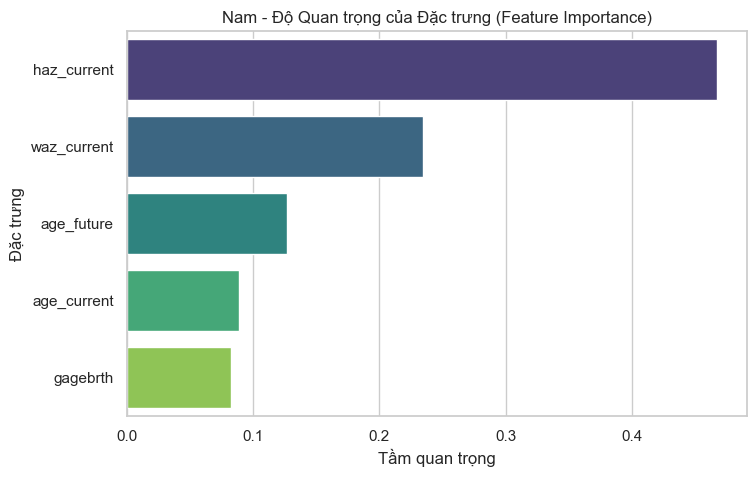


Biểu đồ cho mô hình nữ:


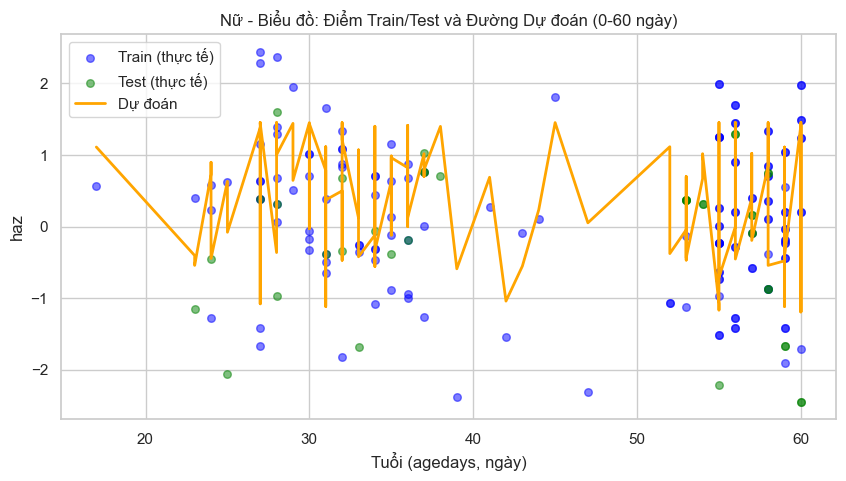

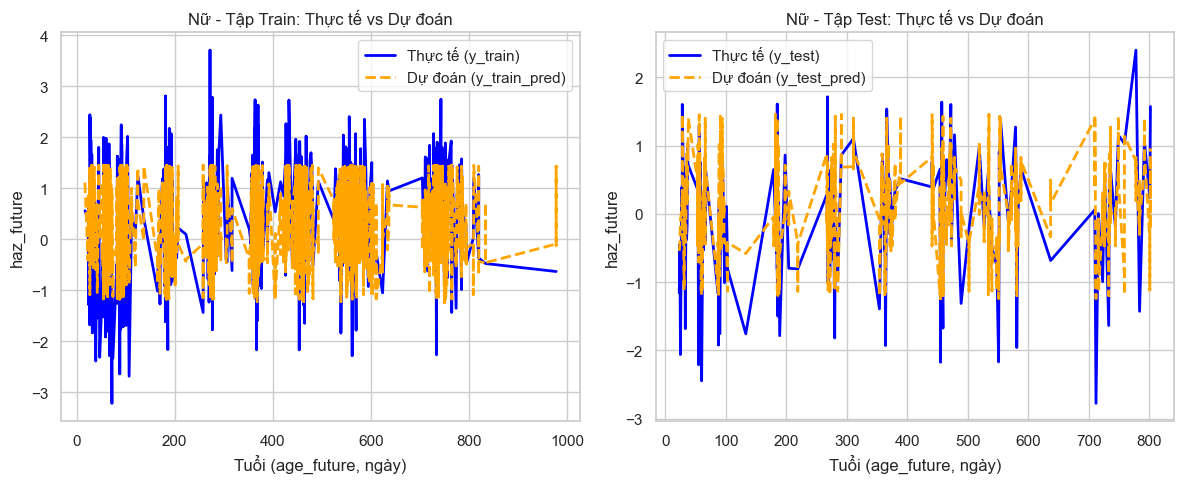

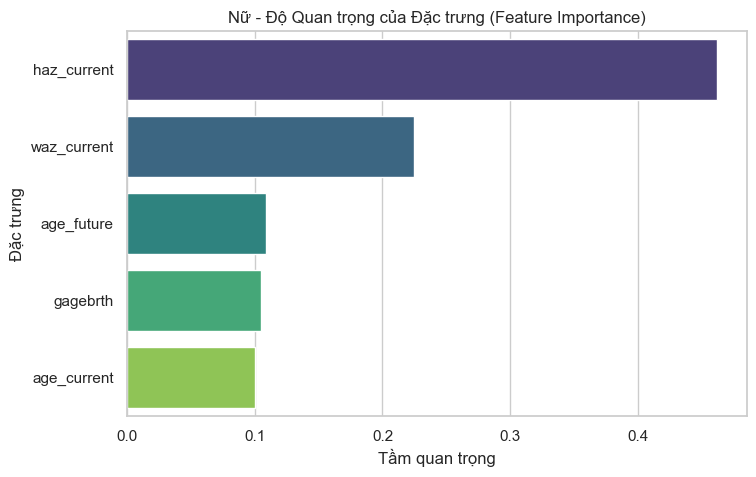

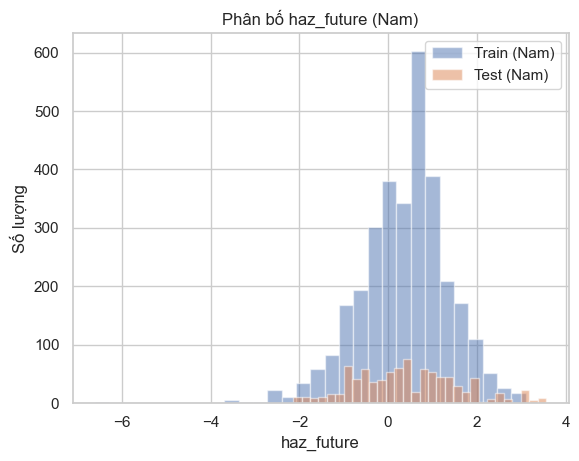

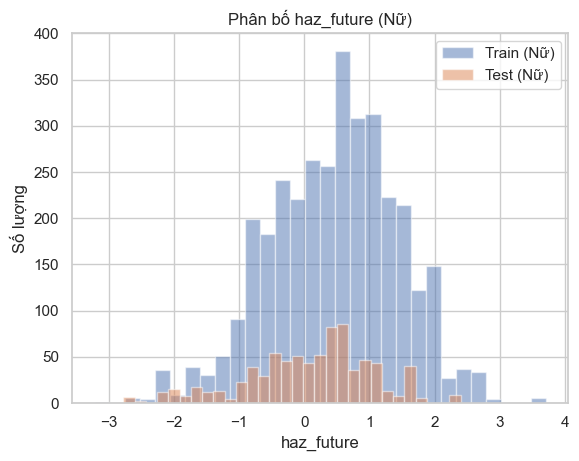

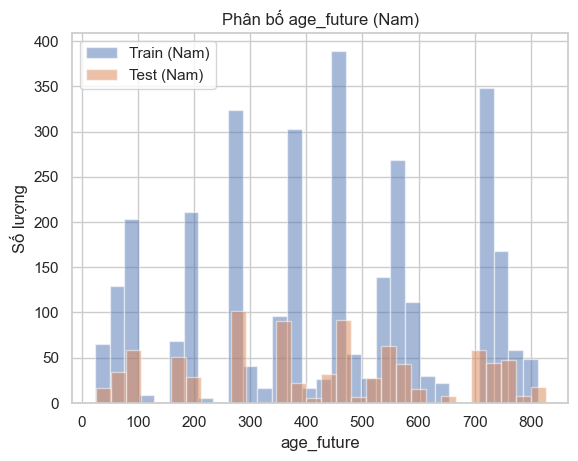

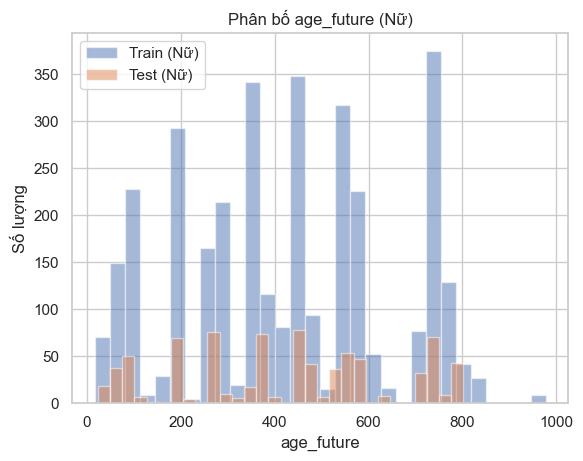

D:\Child_height_prediction\scripts\visualize_haz_model_split_sex.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([y_train_male, y_test_male], labels=['Train (Nam)', 'Test (Nam)'])


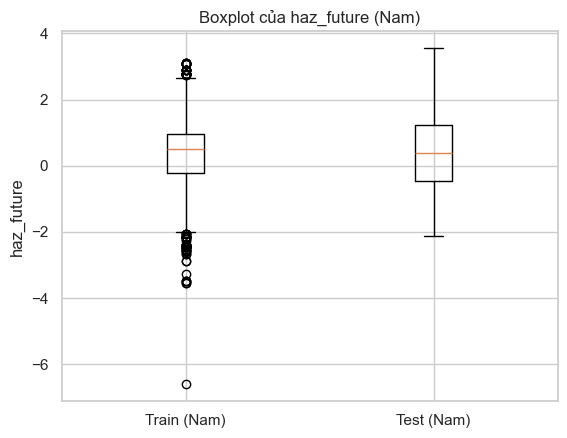

D:\Child_height_prediction\scripts\visualize_haz_model_split_sex.py:178: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([y_train_female, y_test_female], labels=['Train (Nữ)', 'Test (Nữ)'])


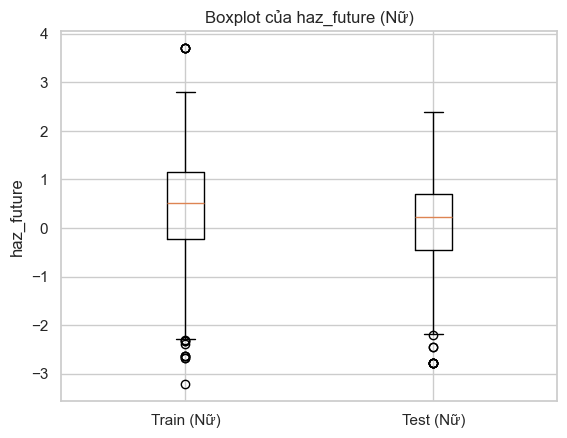

Ma trận tương quan (Nam):
             age_current  age_future  gagebrth  haz_current  waz_current
age_current     1.000000    0.490436  0.007700     0.024456     0.193237
age_future      0.490436    1.000000 -0.003943     0.000485     0.073065
gagebrth        0.007700   -0.003943  1.000000     0.460400     0.392802
haz_current     0.024456    0.000485  0.460400     1.000000     0.691458
waz_current     0.193237    0.073065  0.392802     0.691458     1.000000
Ma trận tương quan (Nữ):
             age_current  age_future  gagebrth  haz_current  waz_current
age_current     1.000000    0.490032 -0.010267     0.054765     0.225527
age_future      0.490032    1.000000  0.007105     0.010685     0.087403
gagebrth       -0.010267    0.007105  1.000000     0.364128     0.321016
haz_current     0.054765    0.010685  0.364128     1.000000     0.704611
waz_current     0.225527    0.087403  0.321016     0.704611     1.000000


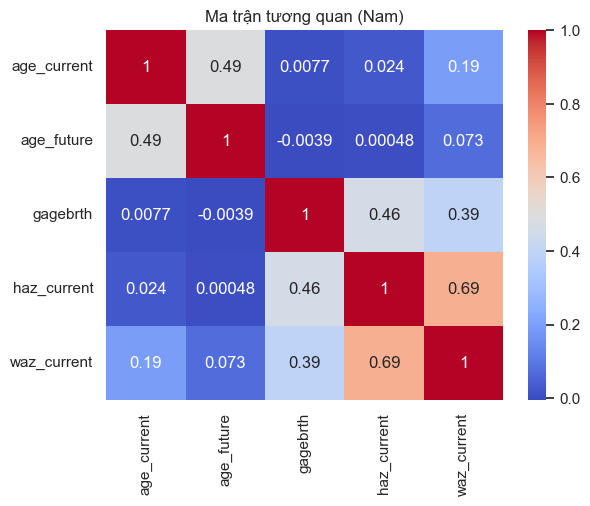

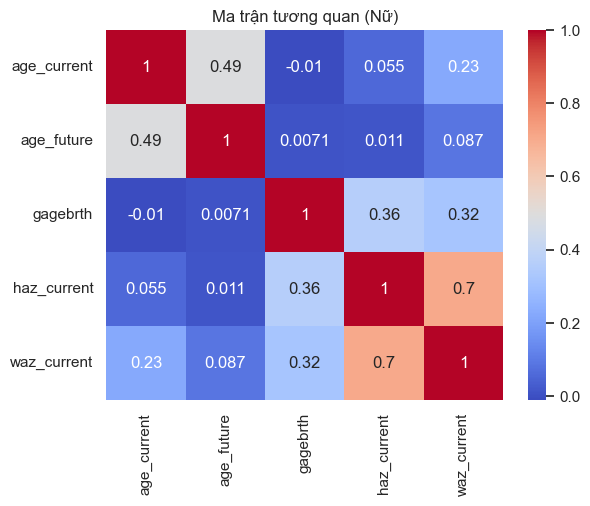

In [20]:
%run "..\scripts\visualize_haz_model_split_sex.py"

In [21]:
%run "..\scripts\train_haz_split_sex.py"

Kết quả cho mô hình nam:
Train Mean Squared Error: 0.5720
Train R² Score: 0.3902
Test Mean Squared Error: 0.5439
Test R² Score: 0.3555

Kết quả cho mô hình nữ:
Train Mean Squared Error: 0.5088
Train R² Score: 0.3545
Test Mean Squared Error: 0.7561
Test R² Score: 0.4546
Đã lưu mô hình nam tại: d:\Child_height_prediction\models\haz_model_male.pkl
Đã lưu mô hình nữ tại: d:\Child_height_prediction\models\haz_model_female.pkl
Đã lưu dữ liệu train và test riêng cho nam và nữ vào thư mục data.


Kiểu của mô hình nam: <class 'sklearn.linear_model._ridge.Ridge'>
Kiểu của mô hình nữ: <class 'sklearn.linear_model._ridge.Ridge'>

Biểu đồ cho mô hình nam:


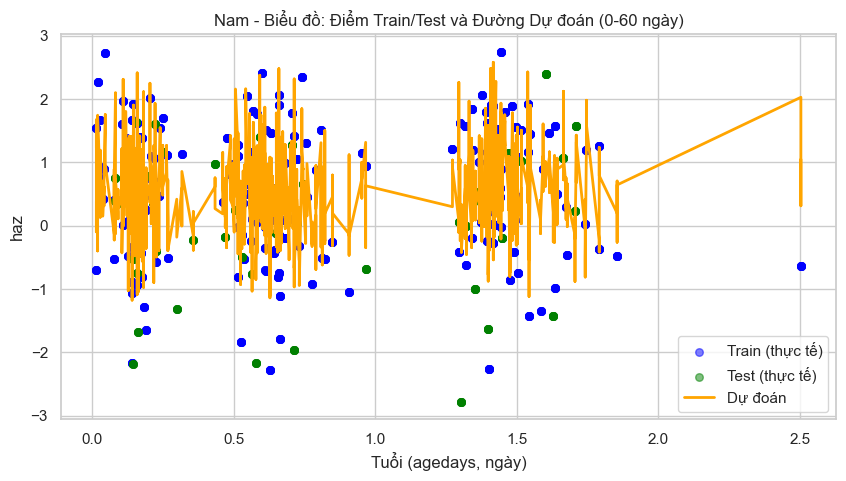

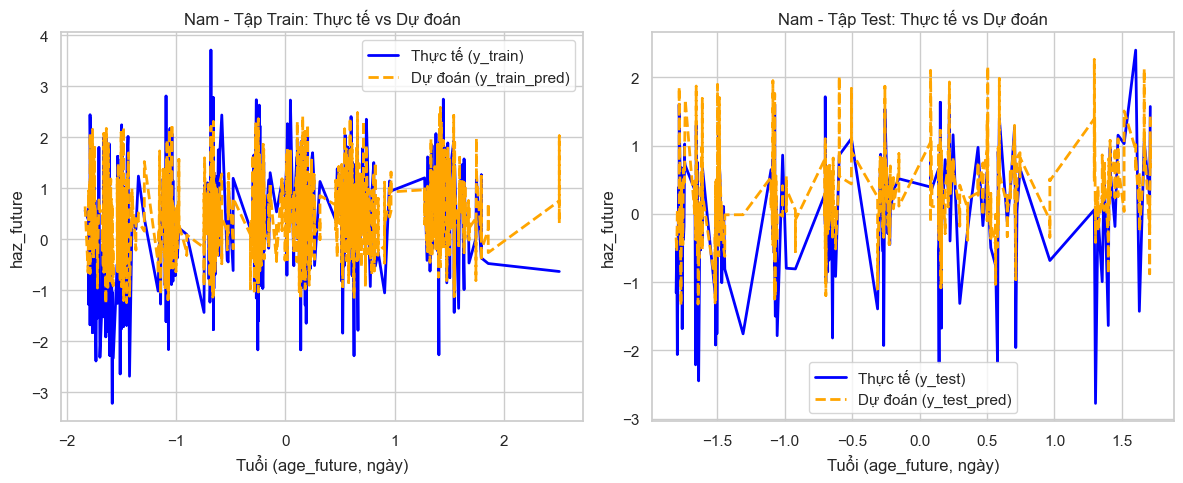

Biểu đồ mức độ quan trọng không áp dụng cho mô hình Nam vì sử dụng Ridge Regression.

Biểu đồ cho mô hình nữ:


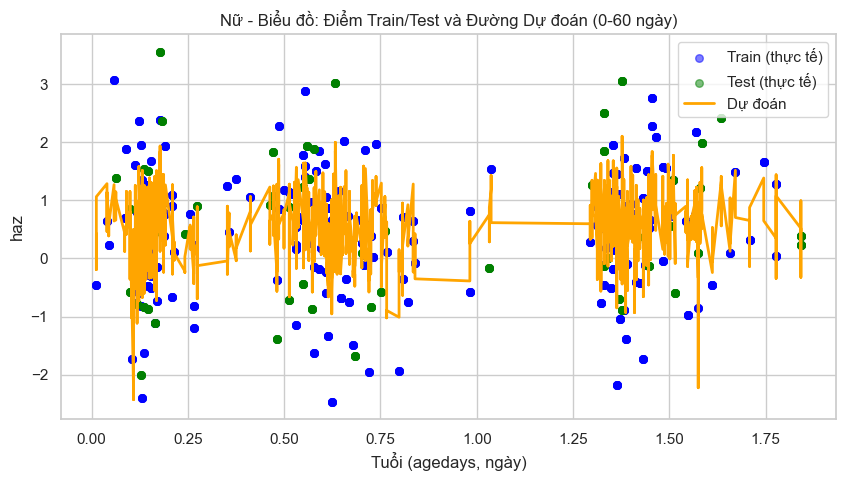

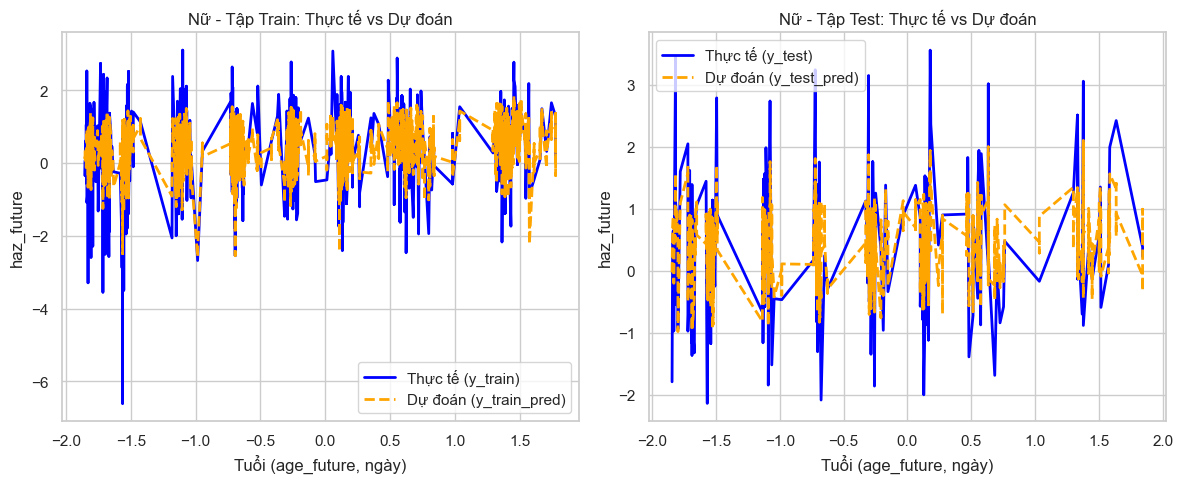

Biểu đồ mức độ quan trọng không áp dụng cho mô hình Nữ vì sử dụng Ridge Regression.


In [22]:
%run "..\scripts\visualize_haz_model_split_sex.py"

In [23]:
%run "..\scripts\train_haz_split_sex.py"

Kết quả cho mô hình nam:
Train Mean Squared Error: 0.2112
Train R² Score: 0.7749
Test Mean Squared Error: 0.5821
Test R² Score: 0.3102

Kết quả cho mô hình nữ:
Train Mean Squared Error: 0.2101
Train R² Score: 0.7335
Test Mean Squared Error: 0.7100
Test R² Score: 0.4878
Đã lưu mô hình nam tại: d:\Child_height_prediction\models\haz_model_male.pkl
Đã lưu mô hình nữ tại: d:\Child_height_prediction\models\haz_model_female.pkl
Đã lưu dữ liệu train và test riêng cho nam và nữ vào thư mục data.


Đang tải dữ liệu từ: D:\Child_height_prediction\data\childhealth-dutch.csv
Số dòng ban đầu: 2000
Đã loại bỏ 52 hàng chứa giá trị NA.
Số dòng sau khi loại bỏ NA: 1948
Đã mã hóa cột 'sex' (Female=1, Male=0) thành 'sex_encoded'.
Đã tạo cột 'is_premature' (1 nếu gagebrth < 259, 0 nếu ngược lại).
Số dòng sau khi đảm bảo kiểu số và kiểm tra NA lần cuối: 1948

--- Bắt đầu xử lý cho giới tính: Nữ ---
Số mẫu huấn luyện (Nữ): 795
Số mẫu kiểm tra (Nữ): 199
Đang huấn luyện mô hình hồi quy cho Nữ...

Kết quả đánh giá mô hình (Nữ):
  Mean Squared Error (MSE): 4.1165
  Root Mean Squared Error (RMSE): 2.0289 cm
  R-squared (R2): 0.9739
Đang vẽ biểu đồ cho Nữ...


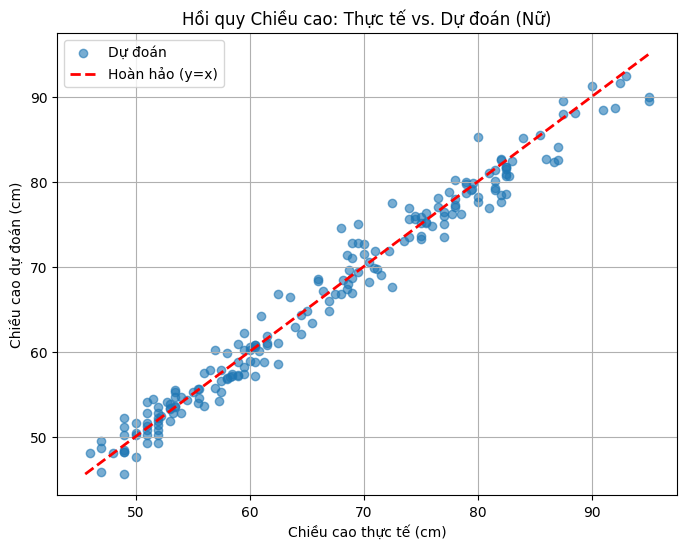

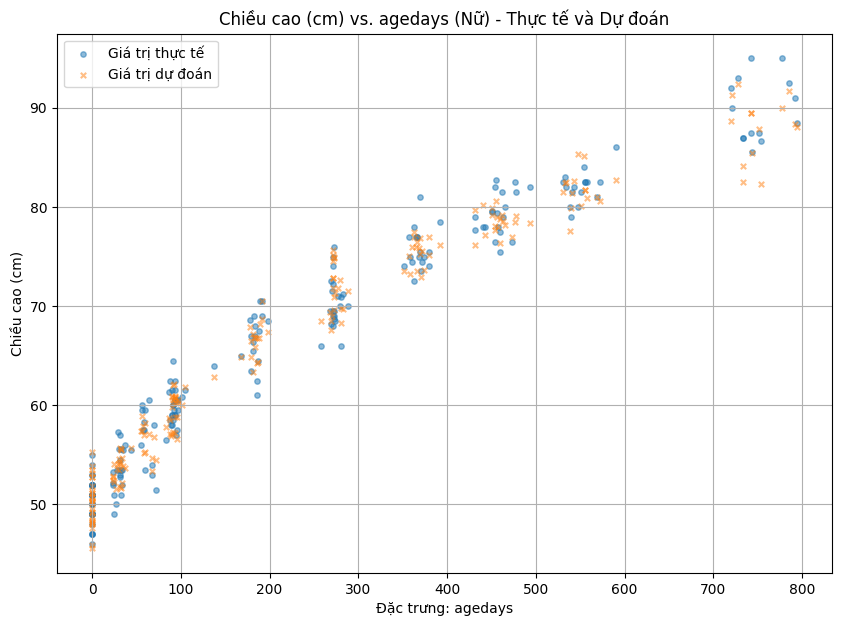

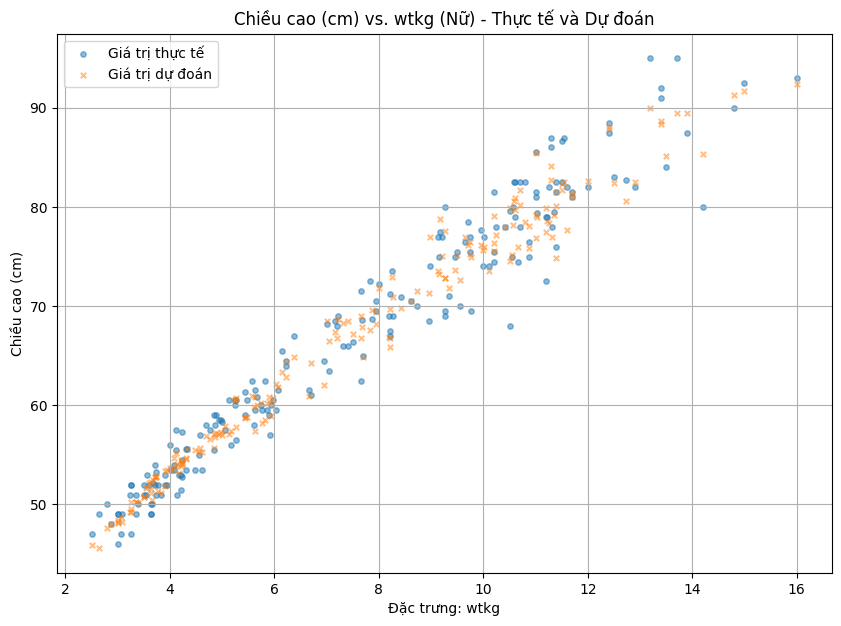


--- Bắt đầu xử lý cho giới tính: Nam ---
Số mẫu huấn luyện (Nam): 763
Số mẫu kiểm tra (Nam): 191
Đang huấn luyện mô hình hồi quy cho Nam...

Kết quả đánh giá mô hình (Nam):
  Mean Squared Error (MSE): 4.5697
  Root Mean Squared Error (RMSE): 2.1377 cm
  R-squared (R2): 0.9694
Đang vẽ biểu đồ cho Nam...


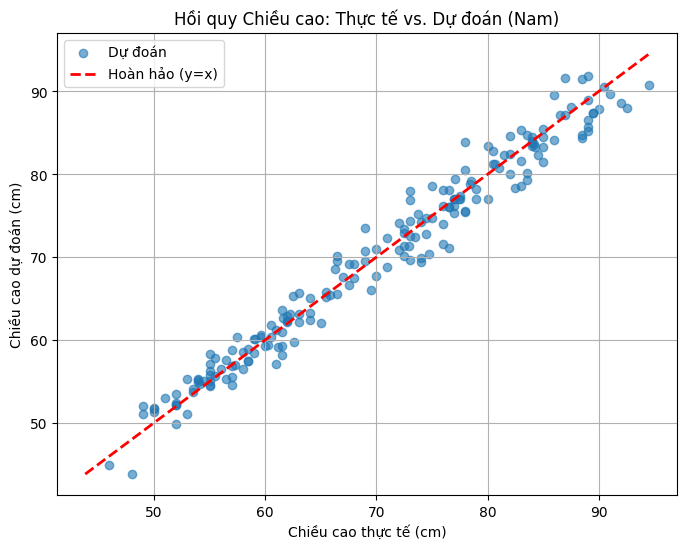

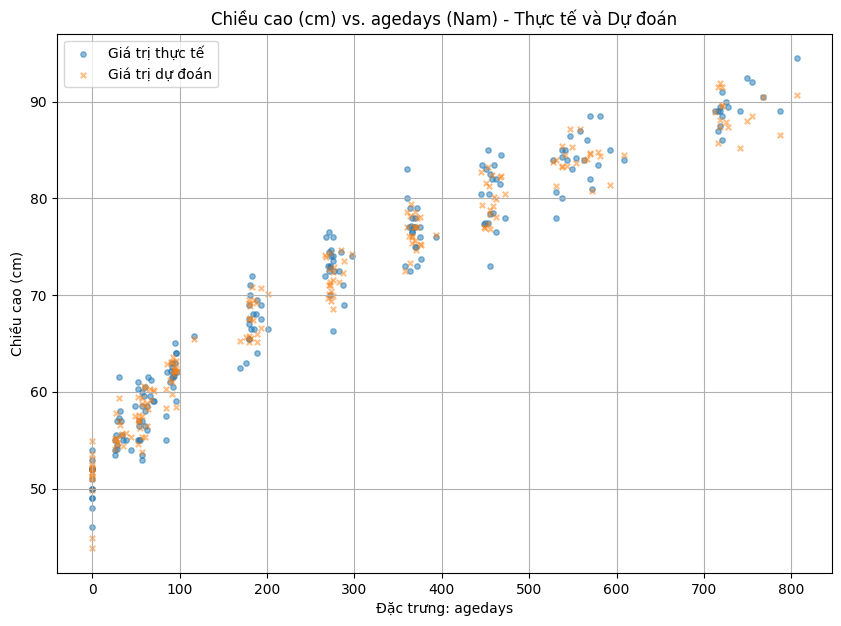

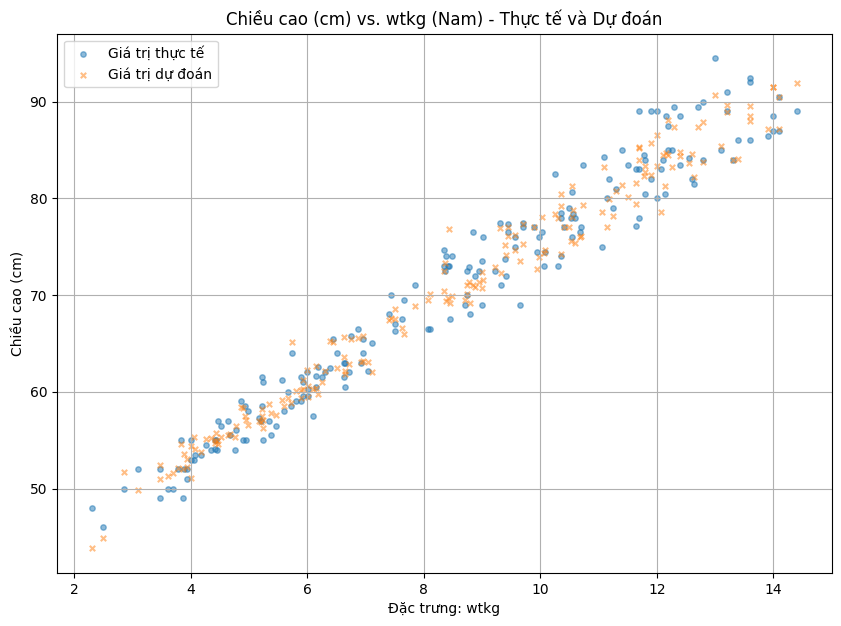

In [1]:
%run "..\scripts\height_model.py"

Đang tải dữ liệu từ: D:\Child_height_prediction\data\childhealth-dutch.csv
Số dòng ban đầu: 2000
Đã loại bỏ 52 hàng chứa giá trị NA.
Số dòng sau khi loại bỏ NA: 1948
Đã mã hóa cột 'sex' (Female=1, Male=0) thành 'sex_encoded'.
Đã tạo cột 'is_premature' (1 nếu gagebrth < 259, 0 nếu ngược lại).
Số dòng sau khi đảm bảo kiểu số và kiểm tra NA lần cuối: 1948
Đã tạo cột 'nutrition_status_waz'.
Đã tạo cột 'nutrition_status_haz'.

--- Bắt đầu xử lý cho: Phân loại WAZ ---
Các lớp tìm thấy cho Phân loại WAZ: ['Normal', 'Severely Underweight', 'Underweight']
Số mẫu huấn luyện (Phân loại WAZ): 1558
Số mẫu kiểm tra (Phân loại WAZ): 390
Đang huấn luyện mô hình Phân loại WAZ...

Kết quả đánh giá (Phân loại WAZ):
  Accuracy: 0.9872

  Classification Report:
                      precision    recall  f1-score   support

              Normal       0.99      1.00      0.99       382
Severely Underweight       1.00      1.00      1.00         1
         Underweight       1.00      0.29      0.44         7


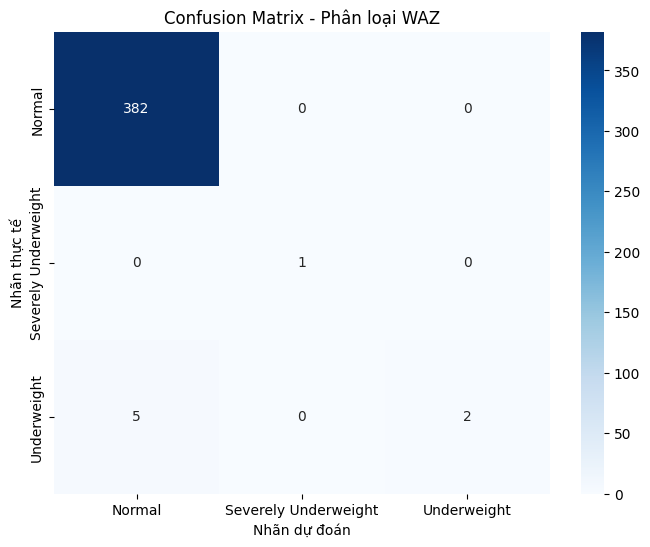


--- Bắt đầu xử lý cho: Phân loại HAZ ---
Các lớp tìm thấy cho Phân loại HAZ: ['Severely stunted', 'Stunted', 'Trẻ bình thường']
Số mẫu huấn luyện (Phân loại HAZ): 1558
Số mẫu kiểm tra (Phân loại HAZ): 390
Đang huấn luyện mô hình Phân loại HAZ...

Kết quả đánh giá (Phân loại HAZ):
  Accuracy: 0.9744

  Classification Report:
                  precision    recall  f1-score   support

Severely stunted       0.00      0.00      0.00         1
         Stunted       0.00      0.00      0.00         9
 Trẻ bình thường       0.97      1.00      0.99       380

        accuracy                           0.97       390
       macro avg       0.32      0.33      0.33       390
    weighted avg       0.95      0.97      0.96       390

Đang vẽ Confusion Matrix cho Phân loại HAZ...


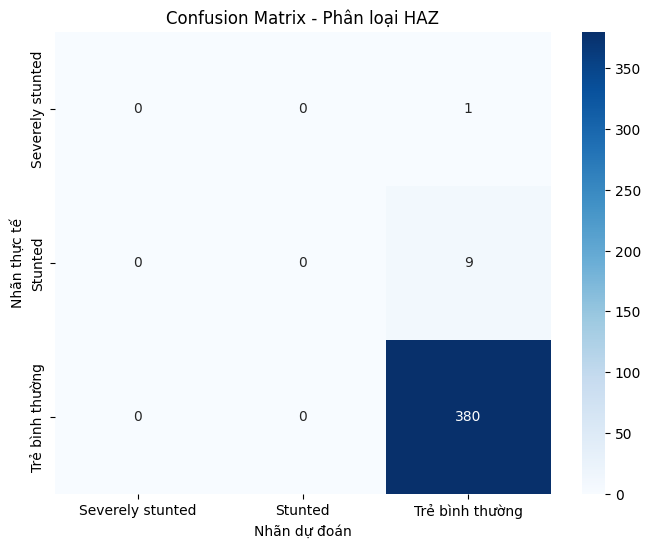

In [1]:
%run "..\scripts\nutrition_model.py"

Chạy thử nghiệm các hàm vẽ biểu đồ (dữ liệu giả):


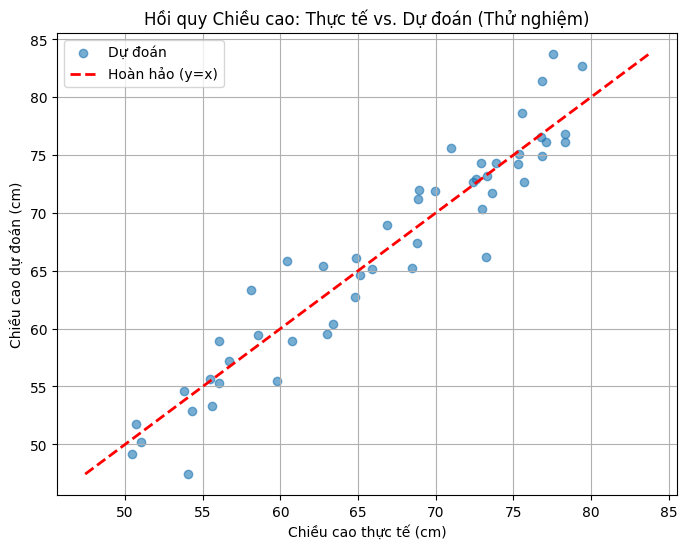

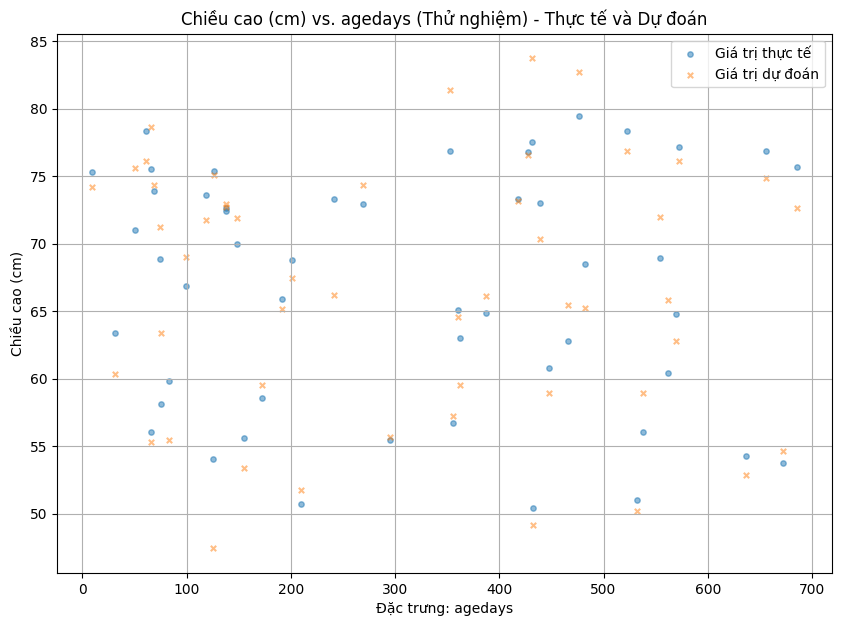

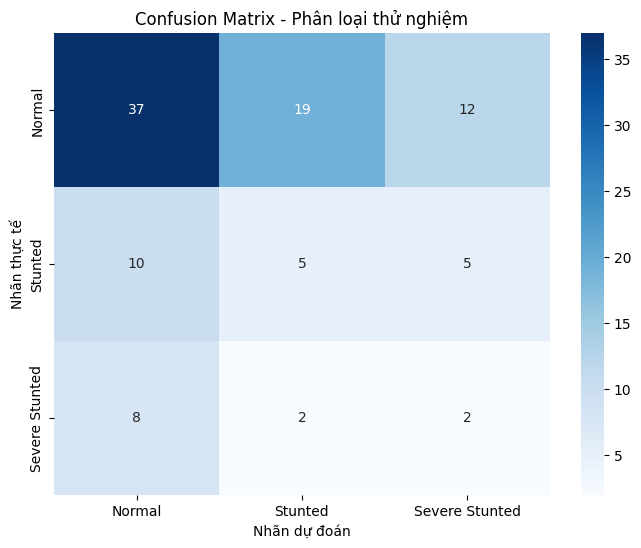

In [2]:
%run "..\scripts\plotting.py"